In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import math

C:\Users\apple\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("final_dataset_hourly.csv", index_col=0, parse_dates=True)

# 填充 UVI > 20 为 NaN
df.loc[df["UVI"] > 20, "UVI"] = np.nan
# 线性插值补全
df = df.interpolate(method="linear")
# 夜间缺失的可填 0
df["UVI"].fillna(0, inplace=True)

# 周期特征编码
df['hour_sin'] = np.sin(2*np.pi*df.index.hour/24)
df['hour_cos'] = np.cos(2*np.pi*df.index.hour/24)
df['day_year_sin'] = np.sin(2*np.pi*df.index.dayofyear/365)
df['day_year_cos'] = np.cos(2*np.pi*df.index.dayofyear/365)

feature_cols = ['temp','rainfall','windspd','windspd_max','wind_d',
                'GHI','DNI','DHI','UVA','ClearSkyGHI','CSI',
                'hour_sin','hour_cos','day_year_sin','day_year_cos']
target_col = 'UVI'

# 数据集切分
train_df = df.loc['2020-01-01':'2021-06-30']
val_df   = df.loc['2021-07-01':'2021-09-30']
test_df  = df.loc['2021-10-01':'2021-12-29']

C:\Users\apple\AppData\Local\Temp\ipykernel_2852\4134516513.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["UVI"].fillna(0, inplace=True)


In [3]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

train_x = x_scaler.fit_transform(train_df[feature_cols])
val_x   = x_scaler.transform(val_df[feature_cols])
test_x  = x_scaler.transform(test_df[feature_cols])

train_y = y_scaler.fit_transform(train_df[[target_col]])
val_y   = y_scaler.transform(val_df[[target_col]])
test_y  = y_scaler.transform(test_df[[target_col]])

In [4]:
class WeatherTimeSeriesDataset(Dataset):
    def __init__(self, data_matrix, target_matrix, seq_len=96, pred_len=24):
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.valid_length = len(data_matrix) - seq_len - pred_len + 1
        self.x = torch.FloatTensor(data_matrix)
        self.y = torch.FloatTensor(target_matrix)

    def __len__(self):
        return self.valid_length

    def __getitem__(self, idx):
        seq_x = self.x[idx:idx+self.seq_len]
        seq_y = self.y[idx+self.seq_len: idx+self.seq_len+self.pred_len, 0]
        return seq_x, seq_y

train_dataset = WeatherTimeSeriesDataset(train_x, train_y)
val_dataset   = WeatherTimeSeriesDataset(val_x, val_y)
test_dataset  = WeatherTimeSeriesDataset(test_x, test_y)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [5]:
import torch
import torch.nn as nn
import math


class AutoCorrelation(nn.Module):
    """
    AutoCorrelation Mechanism with the following two phases:
    (1) period-based dependencies discovery
    (2) time delay aggregation
    This block can replace the self-attention family mechanism seamlessly.
    """
    def __init__(self, mask_flag=True, factor=1, scale=None, attention_dropout=0.1, output_attention=False):
        super(AutoCorrelation, self).__init__()
        self.factor = factor
        self.scale = scale
        self.mask_flag = mask_flag
        self.output_attention = output_attention
        self.dropout = nn.Dropout(attention_dropout)

    def time_delay_agg_training(self, values, corr):
        """
        SpeedUp version of Autocorrelation (a batch-normalization style design)
        This is for the training phase.
        """
        head = values.shape[1]
        channel = values.shape[2]
        length = values.shape[3]
        # find top k
        top_k = int(self.factor * math.log(length))
        mean_value = torch.mean(torch.mean(corr, dim=1), dim=1)
        index = torch.topk(torch.mean(mean_value, dim=0), top_k, dim=-1)[1]
        weights = torch.stack([mean_value[:, index[i]] for i in range(top_k)], dim=-1)
        # update corr
        tmp_corr = torch.softmax(weights, dim=-1)
        # aggregation
        tmp_values = values
        delays_agg = torch.zeros_like(values).float()
        for i in range(top_k):
            pattern = torch.roll(tmp_values, -int(index[i]), -1)
            delays_agg = delays_agg + pattern * \
                         (tmp_corr[:, i].unsqueeze(1).unsqueeze(1).unsqueeze(1).repeat(1, head, channel, length))
        return delays_agg

    def time_delay_agg_inference(self, values, corr):
        """
        SpeedUp version of Autocorrelation (a batch-normalization style design)
        This is for the inference phase.
        """
        batch = values.shape[0]
        head = values.shape[1]
        channel = values.shape[2]
        length = values.shape[3]
        # index init
        init_index = torch.arange(length).unsqueeze(0).unsqueeze(0).unsqueeze(0)\
            .repeat(batch, head, channel, 1).to(values.device)
        # find top k
        top_k = int(self.factor * math.log(length))
        mean_value = torch.mean(torch.mean(corr, dim=1), dim=1)
        weights, delay = torch.topk(mean_value, top_k, dim=-1)
        # update corr
        tmp_corr = torch.softmax(weights, dim=-1)
        # aggregation
        tmp_values = values.repeat(1, 1, 1, 2)
        delays_agg = torch.zeros_like(values).float()
        for i in range(top_k):
            tmp_delay = init_index + delay[:, i].unsqueeze(1).unsqueeze(1).unsqueeze(1).repeat(1, head, channel, length)
            pattern = torch.gather(tmp_values, dim=-1, index=tmp_delay)
            delays_agg = delays_agg + pattern * \
                         (tmp_corr[:, i].unsqueeze(1).unsqueeze(1).unsqueeze(1).repeat(1, head, channel, length))
        return delays_agg

    def time_delay_agg_full(self, values, corr):
        """
        Standard version of Autocorrelation
        """
        batch = values.shape[0]
        head = values.shape[1]
        channel = values.shape[2]
        length = values.shape[3]
        # index init
        init_index = torch.arange(length).unsqueeze(0).unsqueeze(0).unsqueeze(0)\
            .repeat(batch, head, channel, 1).to(values.device)
        # find top k
        top_k = int(self.factor * math.log(length))
        weights, delay = torch.topk(corr, top_k, dim=-1)
        # update corr
        tmp_corr = torch.softmax(weights, dim=-1)
        # aggregation
        tmp_values = values.repeat(1, 1, 1, 2)
        delays_agg = torch.zeros_like(values).float()
        for i in range(top_k):
            tmp_delay = init_index + delay[..., i].unsqueeze(-1)
            pattern = torch.gather(tmp_values, dim=-1, index=tmp_delay)
            delays_agg = delays_agg + pattern * (tmp_corr[..., i].unsqueeze(-1))
        return delays_agg

    def forward(self, queries, keys, values, attn_mask):
        B, L, H, E = queries.shape
        _, S, _, D = values.shape
        if L > S:
            zeros = torch.zeros_like(queries[:, :(L - S), :]).float()
            values = torch.cat([values, zeros], dim=1)
            keys = torch.cat([keys, zeros], dim=1)
        else:
            values = values[:, :L, :, :]
            keys = keys[:, :L, :, :]

        # period-based dependencies
        q_fft = torch.fft.rfft(queries.permute(0, 2, 3, 1).contiguous(), dim=-1)
        k_fft = torch.fft.rfft(keys.permute(0, 2, 3, 1).contiguous(), dim=-1)
        res = q_fft * torch.conj(k_fft)
        corr = torch.fft.irfft(res, n=L, dim=-1)

        # time delay agg
        if self.training:
            V = self.time_delay_agg_training(values.permute(0, 2, 3, 1).contiguous(), corr).permute(0, 3, 1, 2)
        else:
            V = self.time_delay_agg_inference(values.permute(0, 2, 3, 1).contiguous(), corr).permute(0, 3, 1, 2)

        if self.output_attention:
            return (V.contiguous(), corr.permute(0, 3, 1, 2))
        else:
            return (V.contiguous(), None)


class AutoCorrelationLayer(nn.Module):
    def __init__(self, correlation, d_model, n_heads, d_keys=None,
                 d_values=None):
        super(AutoCorrelationLayer, self).__init__()

        d_keys = d_keys or (d_model // n_heads)
        d_values = d_values or (d_model // n_heads)

        self.inner_correlation = correlation
        self.query_projection = nn.Linear(d_model, d_keys * n_heads)
        self.key_projection = nn.Linear(d_model, d_keys * n_heads)
        self.value_projection = nn.Linear(d_model, d_values * n_heads)
        self.out_projection = nn.Linear(d_values * n_heads, d_model)
        self.n_heads = n_heads

    def forward(self, queries, keys, values, attn_mask):
        B, L, _ = queries.shape
        _, S, _ = keys.shape
        H = self.n_heads

        queries = self.query_projection(queries).view(B, L, H, -1)
        keys = self.key_projection(keys).view(B, S, H, -1)
        values = self.value_projection(values).view(B, S, H, -1)

        out, attn = self.inner_correlation(
            queries,
            keys,
            values,
            attn_mask
        )
        out = out.view(B, L, -1)

        return self.out_projection(out), attn

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class my_Layernorm(nn.Module):
    """
    Special designed layernorm for the seasonal part
    """
    def __init__(self, channels):
        super(my_Layernorm, self).__init__()
        self.layernorm = nn.LayerNorm(channels)

    def forward(self, x):
        x_hat = self.layernorm(x)
        bias = torch.mean(x_hat, dim=1).unsqueeze(1).repeat(1, x.shape[1], 1)
        return x_hat - bias


class moving_avg(nn.Module):
    """
    Moving average block to highlight the trend of time series
    """
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x


class series_decomp(nn.Module):
    """
    Series decomposition block
    """
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean


class EncoderLayer(nn.Module):
    """
    Autoformer encoder layer with the progressive decomposition architecture
    """
    def __init__(self, attention, d_model, d_ff=None, moving_avg=25, dropout=0.1, activation="relu"):
        super(EncoderLayer, self).__init__()
        d_ff = d_ff or 4 * d_model
        self.attention = attention
        self.conv1 = nn.Conv1d(in_channels=d_model, out_channels=d_ff, kernel_size=1, bias=False)
        self.conv2 = nn.Conv1d(in_channels=d_ff, out_channels=d_model, kernel_size=1, bias=False)
        self.decomp1 = series_decomp(moving_avg)
        self.decomp2 = series_decomp(moving_avg)
        self.dropout = nn.Dropout(dropout)
        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x, attn_mask=None):
        new_x, attn = self.attention(
            x, x, x,
            attn_mask=attn_mask
        )
        x = x + self.dropout(new_x)
        x, _ = self.decomp1(x)
        y = x
        y = self.dropout(self.activation(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))
        res, _ = self.decomp2(x + y)
        return res, attn


class Encoder(nn.Module):
    """
    Autoformer encoder
    """
    def __init__(self, attn_layers, conv_layers=None, norm_layer=None):
        super(Encoder, self).__init__()
        self.attn_layers = nn.ModuleList(attn_layers)
        self.conv_layers = nn.ModuleList(conv_layers) if conv_layers is not None else None
        self.norm = norm_layer

    def forward(self, x, attn_mask=None):
        attns = []
        if self.conv_layers is not None:
            for attn_layer, conv_layer in zip(self.attn_layers, self.conv_layers):
                x, attn = attn_layer(x, attn_mask=attn_mask)
                x = conv_layer(x)
                attns.append(attn)
            x, attn = self.attn_layers[-1](x)
            attns.append(attn)
        else:
            for attn_layer in self.attn_layers:
                x, attn = attn_layer(x, attn_mask=attn_mask)
                attns.append(attn)

        if self.norm is not None:
            x = self.norm(x)

        return x, attns


class DecoderLayer(nn.Module):
    """
    Autoformer decoder layer with the progressive decomposition architecture
    """
    def __init__(self, self_attention, cross_attention, d_model, c_out, d_ff=None,
                 moving_avg=25, dropout=0.1, activation="relu"):
        super(DecoderLayer, self).__init__()
        d_ff = d_ff or 4 * d_model
        self.self_attention = self_attention
        self.cross_attention = cross_attention
        self.conv1 = nn.Conv1d(in_channels=d_model, out_channels=d_ff, kernel_size=1, bias=False)
        self.conv2 = nn.Conv1d(in_channels=d_ff, out_channels=d_model, kernel_size=1, bias=False)
        self.decomp1 = series_decomp(moving_avg)
        self.decomp2 = series_decomp(moving_avg)
        self.decomp3 = series_decomp(moving_avg)
        self.dropout = nn.Dropout(dropout)
        self.projection = nn.Conv1d(in_channels=d_model, out_channels=c_out, kernel_size=3, stride=1, padding=1,
                                    padding_mode='circular', bias=False)
        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x, cross, x_mask=None, cross_mask=None):
        x = x + self.dropout(self.self_attention(
            x, x, x,
            attn_mask=x_mask
        )[0])
        x, trend1 = self.decomp1(x)
        x = x + self.dropout(self.cross_attention(
            x, cross, cross,
            attn_mask=cross_mask
        )[0])
        x, trend2 = self.decomp2(x)
        y = x
        y = self.dropout(self.activation(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))
        x, trend3 = self.decomp3(x + y)

        residual_trend = trend1 + trend2 + trend3
        residual_trend = self.projection(residual_trend.permute(0, 2, 1)).transpose(1, 2)
        return x, residual_trend


class Decoder(nn.Module):
    """
    Autoformer encoder
    """
    def __init__(self, layers, norm_layer=None, projection=None):
        super(Decoder, self).__init__()
        self.layers = nn.ModuleList(layers)
        self.norm = norm_layer
        self.projection = projection

    def forward(self, x, cross, x_mask=None, cross_mask=None, trend=None):
        for layer in self.layers:
            x, residual_trend = layer(x, cross, x_mask=x_mask, cross_mask=cross_mask)
            trend = trend + residual_trend

        if self.norm is not None:
            x = self.norm(x)

        if self.projection is not None:
            x = self.projection(x)
        return x, trend

In [7]:
import torch
import torch.nn as nn
import math

def compared_version(ver1, ver2):
    """
    :param ver1
    :param ver2
    :return: ver1< = >ver2 False/True
    """
    list1 = str(ver1).split(".")
    list2 = str(ver2).split(".")
    
    for i in range(len(list1)) if len(list1) < len(list2) else range(len(list2)):
        if int(list1[i]) == int(list2[i]):
            pass
        elif int(list1[i]) < int(list2[i]):
            return -1
        else:
            return 1
    
    if len(list1) == len(list2):
        return True
    elif len(list1) < len(list2):
        return False
    else:
        return True

class PositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEmbedding, self).__init__()
        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, d_model).float()
        pe.require_grad = False

        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = (torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)).exp()

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return self.pe[:, :x.size(1)]


class TokenEmbedding(nn.Module):
    def __init__(self, c_in, d_model):
        super(TokenEmbedding, self).__init__()
        padding = 1 if compared_version(torch.__version__, '1.5.0') else 2
        self.tokenConv = nn.Conv1d(in_channels=c_in, out_channels=d_model,
                                   kernel_size=3, padding=padding, padding_mode='circular', bias=False)
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu')

    def forward(self, x):
        x = self.tokenConv(x.permute(0, 2, 1)).transpose(1, 2)
        return x


class FixedEmbedding(nn.Module):
    def __init__(self, c_in, d_model):
        super(FixedEmbedding, self).__init__()

        w = torch.zeros(c_in, d_model).float()
        w.require_grad = False

        position = torch.arange(0, c_in).float().unsqueeze(1)
        div_term = (torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)).exp()

        w[:, 0::2] = torch.sin(position * div_term)
        w[:, 1::2] = torch.cos(position * div_term)

        self.emb = nn.Embedding(c_in, d_model)
        self.emb.weight = nn.Parameter(w, requires_grad=False)

    def forward(self, x):
        return self.emb(x).detach()


class TemporalEmbedding(nn.Module):
    def __init__(self, d_model, embed_type='fixed', freq='h'):
        super(TemporalEmbedding, self).__init__()

        minute_size = 4
        hour_size = 24
        weekday_size = 7
        day_size = 32
        month_size = 13

        Embed = FixedEmbedding if embed_type == 'fixed' else nn.Embedding
        if freq == 't':
            self.minute_embed = Embed(minute_size, d_model)
        self.hour_embed = Embed(hour_size, d_model)
        self.weekday_embed = Embed(weekday_size, d_model)
        self.day_embed = Embed(day_size, d_model)
        self.month_embed = Embed(month_size, d_model)

    def forward(self, x):
        x = x.long()

        minute_x = self.minute_embed(x[:, :, 4]) if hasattr(self, 'minute_embed') else 0.
        hour_x = self.hour_embed(x[:, :, 3])
        weekday_x = self.weekday_embed(x[:, :, 2])
        day_x = self.day_embed(x[:, :, 1])
        month_x = self.month_embed(x[:, :, 0])

        return hour_x + weekday_x + day_x + month_x + minute_x


class TimeFeatureEmbedding(nn.Module):
    def __init__(self, d_model, embed_type='timeF', freq='h'):
        super(TimeFeatureEmbedding, self).__init__()

        freq_map = {'h': 4, 't': 5, 's': 6, 'm': 1, 'a': 1, 'w': 2, 'd': 3, 'b': 3}
        d_inp = freq_map[freq]
        self.embed = nn.Linear(d_inp, d_model, bias=False)

    def forward(self, x):
        return self.embed(x)


class DataEmbedding(nn.Module):
    def __init__(self, c_in, d_model, embed_type='fixed', freq='h', dropout=0.1):
        super(DataEmbedding, self).__init__()

        self.value_embedding = TokenEmbedding(c_in=c_in, d_model=d_model)
        self.position_embedding = PositionalEmbedding(d_model=d_model)
        self.temporal_embedding = TemporalEmbedding(d_model=d_model, embed_type=embed_type,
                                                    freq=freq) if embed_type != 'timeF' else TimeFeatureEmbedding(
            d_model=d_model, embed_type=embed_type, freq=freq)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, x_mark):
        x = self.value_embedding(x) + self.temporal_embedding(x_mark) + self.position_embedding(x)
        return self.dropout(x)


class DataEmbedding_wo_pos(nn.Module):
    def __init__(self, c_in, d_model, embed_type='fixed', freq='h', dropout=0.1):
        super(DataEmbedding_wo_pos, self).__init__()

        self.value_embedding = TokenEmbedding(c_in=c_in, d_model=d_model)
        self.position_embedding = PositionalEmbedding(d_model=d_model)
        self.temporal_embedding = TemporalEmbedding(d_model=d_model, embed_type=embed_type,
                                                    freq=freq) if embed_type != 'timeF' else TimeFeatureEmbedding(
            d_model=d_model, embed_type=embed_type, freq=freq)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, x_mark):
        x = self.value_embedding(x) + self.temporal_embedding(x_mark)
        return self.dropout(x)

In [8]:
import torch.nn as nn
import torch.nn.functional as F


class ConvLayer(nn.Module):
    def __init__(self, c_in):
        super(ConvLayer, self).__init__()
        self.downConv = nn.Conv1d(in_channels=c_in,
                                  out_channels=c_in,
                                  kernel_size=3,
                                  padding=2,
                                  padding_mode='circular')
        self.norm = nn.BatchNorm1d(c_in)
        self.activation = nn.ELU()
        self.maxPool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        x = self.downConv(x.permute(0, 2, 1))
        x = self.norm(x)
        x = self.activation(x)
        x = self.maxPool(x)
        x = x.transpose(1, 2)
        return x


class EncoderLayer(nn.Module):
    def __init__(self, attention, d_model, d_ff=None, dropout=0.1, activation="relu"):
        super(EncoderLayer, self).__init__()
        d_ff = d_ff or 4 * d_model
        self.attention = attention
        self.conv1 = nn.Conv1d(in_channels=d_model, out_channels=d_ff, kernel_size=1)
        self.conv2 = nn.Conv1d(in_channels=d_ff, out_channels=d_model, kernel_size=1)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x, attn_mask=None):
        new_x, attn = self.attention(
            x, x, x,
            attn_mask=attn_mask
        )
        x = x + self.dropout(new_x)

        y = x = self.norm1(x)
        y = self.dropout(self.activation(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))

        return self.norm2(x + y), attn


class Encoder(nn.Module):
    def __init__(self, attn_layers, conv_layers=None, norm_layer=None):
        super(Encoder, self).__init__()
        self.attn_layers = nn.ModuleList(attn_layers)
        self.conv_layers = nn.ModuleList(conv_layers) if conv_layers is not None else None
        self.norm = norm_layer

    def forward(self, x, attn_mask=None):
        # x [B, L, D]
        attns = []
        if self.conv_layers is not None:
            for attn_layer, conv_layer in zip(self.attn_layers, self.conv_layers):
                x, attn = attn_layer(x, attn_mask=attn_mask)
                x = conv_layer(x)
                attns.append(attn)
            x, attn = self.attn_layers[-1](x)
            attns.append(attn)
        else:
            for attn_layer in self.attn_layers:
                x, attn = attn_layer(x, attn_mask=attn_mask)
                attns.append(attn)

        if self.norm is not None:
            x = self.norm(x)

        return x, attns


class DecoderLayer(nn.Module):
    def __init__(self, self_attention, cross_attention, d_model, d_ff=None,
                 dropout=0.1, activation="relu"):
        super(DecoderLayer, self).__init__()
        d_ff = d_ff or 4 * d_model
        self.self_attention = self_attention
        self.cross_attention = cross_attention
        self.conv1 = nn.Conv1d(in_channels=d_model, out_channels=d_ff, kernel_size=1)
        self.conv2 = nn.Conv1d(in_channels=d_ff, out_channels=d_model, kernel_size=1)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x, cross, x_mask=None, cross_mask=None):
        x = x + self.dropout(self.self_attention(
            x, x, x,
            attn_mask=x_mask
        )[0])
        x = self.norm1(x)

        x = x + self.dropout(self.cross_attention(
            x, cross, cross,
            attn_mask=cross_mask
        )[0])

        y = x = self.norm2(x)
        y = self.dropout(self.activation(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))

        return self.norm3(x + y)


class Decoder(nn.Module):
    def __init__(self, layers, norm_layer=None, projection=None):
        super(Decoder, self).__init__()
        self.layers = nn.ModuleList(layers)
        self.norm = norm_layer
        self.projection = projection

    def forward(self, x, cross, x_mask=None, cross_mask=None):
        for layer in self.layers:
            x = layer(x, cross, x_mask=x_mask, cross_mask=cross_mask)

        if self.norm is not None:
            x = self.norm(x)

        if self.projection is not None:
            x = self.projection(x)
        return x

In [9]:
import torch
import torch.nn as nn

class Model(nn.Module):
    """
    Autoformer - simplified to match the current EncoderLayer/DecoderLayer definitions
    """
    def __init__(self, configs):
        super(Model, self).__init__()
        self.seq_len = configs.seq_len
        self.label_len = getattr(configs, "label_len", configs.seq_len)
        self.pred_len = configs.pred_len
        self.output_attention = getattr(configs, "output_attention", False)

        # Embedding
        self.enc_embedding = DataEmbedding_wo_pos(
            configs.enc_in, configs.d_model, configs.embed, configs.freq, configs.dropout
        )
        self.dec_embedding = DataEmbedding_wo_pos(
            configs.dec_in, configs.d_model, configs.embed, configs.freq, configs.dropout
        )

        # Encoder
        self.encoder = Encoder(
            [
                EncoderLayer(
                    attention=AutoCorrelationLayer(
                        AutoCorrelation(False, configs.factor, attention_dropout=configs.dropout,
                                        output_attention=configs.output_attention),
                        configs.d_model, configs.n_heads
                    ),
                    d_model=configs.d_model,
                    d_ff=configs.d_ff,
                    dropout=configs.dropout,
                    activation=configs.activation
                ) for _ in range(configs.e_layers)
            ]
        )

        # Decoder
        self.decoder = Decoder(
            [
                DecoderLayer(
                    self_attention=AutoCorrelationLayer(
                        AutoCorrelation(True, configs.factor, attention_dropout=configs.dropout,
                                        output_attention=False),
                        configs.d_model, configs.n_heads
                    ),
                    cross_attention=AutoCorrelationLayer(
                        AutoCorrelation(False, configs.factor, attention_dropout=configs.dropout,
                                        output_attention=False),
                        configs.d_model, configs.n_heads
                    ),
                    d_model=configs.d_model,
                    d_ff=configs.d_ff,
                    dropout=configs.dropout,
                    activation=configs.activation
                ) for _ in range(configs.d_layers)
            ],
            projection=nn.Linear(configs.d_model, configs.c_out, bias=True)
        )

    def forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec,
                enc_self_mask=None, dec_self_mask=None, dec_enc_mask=None):
        # embedding
        enc_out = self.enc_embedding(x_enc, x_mark_enc)
        enc_out, attns = self.encoder(enc_out, attn_mask=enc_self_mask)

        dec_out = self.dec_embedding(x_dec, x_mark_dec)
        dec_out = self.decoder(dec_out, enc_out, x_mask=dec_self_mask, cross_mask=dec_enc_mask)

        return dec_out[:, -self.pred_len:, :]  # output shape [B, pred_len, c_out]

In [10]:
class Config:
    seq_len = 96
    label_len = 48
    pred_len = 24
    enc_in = len(feature_cols)
    dec_in = len(feature_cols)
    c_out = 1
    d_model = 128
    embed = 'timeF'
    freq = 'h'
    dropout = 0.05
    factor = 5
    n_heads = 8
    e_layers = 2
    d_layers = 1
    d_ff = 256
    moving_avg = 25
    activation = 'relu'
    output_attention = False

cfg = Config()

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Model(cfg).to(device)

In [11]:
import numpy as np
import pandas as pd

def make_time_features(df):

    dt = pd.to_datetime(df.index)

    return np.stack([
        dt.month.values,
        dt.day.values,
        dt.weekday.values,
        dt.hour.values
    ], axis=1)

train_mark = make_time_features(train_df)
val_mark   = make_time_features(val_df)
test_mark  = make_time_features(test_df)

print(train_mark.shape)
print(val_mark.shape)
print(test_mark.shape)

(13123, 4)
(2208, 4)
(2141, 4)


In [12]:
from torch.utils.data import Dataset

class AutoformerDataset(Dataset):

    def __init__(
        self,
        x,
        y,
        mark,
        seq_len=96,
        label_len=48,
        pred_len=24
    ):

        self.x = torch.FloatTensor(x)
        self.y = torch.FloatTensor(y)
        self.mark = torch.LongTensor(mark)

        self.seq_len = seq_len
        self.label_len = label_len
        self.pred_len = pred_len

        self.length = (
            len(x)
            - seq_len
            - pred_len
            + 1
        )

    def __len__(self):
        return self.length

    def __getitem__(self, idx):

        s_begin = idx
        s_end   = s_begin + self.seq_len

        r_begin = s_end - self.label_len
        r_end   = r_begin + self.label_len + self.pred_len

        x_enc = self.x[s_begin:s_end]

        x_mark_enc = self.mark[s_begin:s_end]

        dec_y = self.y[r_begin:r_end]

        x_dec = torch.zeros(
            self.label_len+self.pred_len,
            self.x.shape[1]
        )

        x_dec[:self.label_len] = self.x[r_begin:r_begin+self.label_len]

        x_mark_dec = self.mark[r_begin:r_end]

        target = self.y[
            s_end:s_end+self.pred_len,
            0
        ]

        return (
            x_enc,
            x_mark_enc,
            x_dec,
            x_mark_dec,
            target
        )

In [13]:
seq_len = 96
label_len = 48
pred_len = 24

train_dataset = AutoformerDataset(
    train_x,
    train_y,
    train_mark,
    seq_len,
    label_len,
    pred_len
)

val_dataset = AutoformerDataset(
    val_x,
    val_y,
    val_mark,
    seq_len,
    label_len,
    pred_len
)

test_dataset = AutoformerDataset(
    test_x,
    test_y,
    test_mark,
    seq_len,
    label_len,
    pred_len
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

13004
2089
2022


In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [28]:
class Config:

    seq_len = 96
    label_len = 48
    pred_len = 24

    enc_in = len(feature_cols)
    dec_in = len(feature_cols)

    c_out = 1

    d_model = 64

    n_heads = 4

    e_layers = 2
    d_layers = 1

    d_ff = 128

    factor = 5

    embed = "fixed"

    freq = "h"

    dropout = 0.2

    activation = "relu"

    output_attention = False

cfg = Config()

In [ ]:
def train_autoformer(
    model,
    train_loader,
    val_loader,
    epochs=100,
    patience=10,
    device="cpu"
):

    model = model.to(device)

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-3
    )

    best_val_loss = float("inf")
    best_weights = None
    counter = 0

    for epoch in range(epochs):

        # ====================
        # Train
        # ====================

        model.train()

        train_loss = 0.0

        for (
            x_enc,
            x_mark_enc,
            x_dec,
            x_mark_dec,
            target
        ) in train_loader:

            x_enc = x_enc.to(device)
            x_mark_enc = x_mark_enc.to(device)

            x_dec = x_dec.to(device)
            x_mark_dec = x_mark_dec.to(device)

            target = target.to(device)

            optimizer.zero_grad()

            pred = model(
                x_enc,
                x_mark_enc,
                x_dec,
                x_mark_dec
            )

            pred = pred.squeeze(-1)

            loss = criterion(pred, target)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=2.0
            )

            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ====================
        # Validation
        # ====================

        model.eval()

        val_loss = 0.0

        with torch.no_grad():

            for (
                x_enc,
                x_mark_enc,
                x_dec,
                x_mark_dec,
                target
            ) in val_loader:

                x_enc = x_enc.to(device)
                x_mark_enc = x_mark_enc.to(device)

                x_dec = x_dec.to(device)
                x_mark_dec = x_mark_dec.to(device)

                target = target.to(device)

                pred = model(
                    x_enc,
                    x_mark_enc,
                    x_dec,
                    x_mark_dec
                )

                pred = pred.squeeze(-1)

                loss = criterion(pred, target)

                val_loss += loss.item()

        val_loss /= len(val_loader)

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train={train_loss:.4f} | "
            f"Val={val_loss:.4f}"
        )

        # ====================
        # Early Stopping
        # ====================

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_weights = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

            counter = 0

        else:

            counter += 1

            if counter >= patience:

                print(
                    f"\nEarly stopping "
                    f"(best val={best_val_loss:.4f})"
                )
                break

    # ====================
    # Restore Best Model
    # ====================

    if best_weights is not None:
        model.load_state_dict(best_weights)

    print(
        f"\nBest Validation Loss = "
        f"{best_val_loss:.4f}"
    )

    return model

In [31]:
trained_model = train_autoformer(
    model,
    train_loader,
    val_loader,
    epochs=100,
    patience=10,
    device=device
)

Epoch 001 | Train=0.0365 | Val=0.1787
Epoch 002 | Train=0.0303 | Val=0.1604
Epoch 003 | Train=0.0290 | Val=0.1950
Epoch 004 | Train=0.0307 | Val=0.1870
Epoch 005 | Train=0.0290 | Val=0.1678
Epoch 006 | Train=0.0302 | Val=0.1689
Epoch 007 | Train=0.0273 | Val=0.1746
Epoch 008 | Train=0.0291 | Val=0.1899
Epoch 009 | Train=0.0308 | Val=0.1764
Epoch 010 | Train=0.0281 | Val=0.1570
Epoch 011 | Train=0.0292 | Val=0.1682
Epoch 012 | Train=0.0277 | Val=0.1903
Epoch 013 | Train=0.0278 | Val=0.1812
Epoch 014 | Train=0.0303 | Val=0.1909
Epoch 015 | Train=0.0294 | Val=0.1815
Epoch 016 | Train=0.0279 | Val=0.1807
Epoch 017 | Train=0.0294 | Val=0.1841
Epoch 018 | Train=0.0291 | Val=0.1890
Epoch 019 | Train=0.0280 | Val=0.1990
Epoch 020 | Train=0.0290 | Val=0.1818

Early stopping (best val=0.1570)

Best Validation Loss = 0.1570


In [32]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

model.eval()

preds = []
trues = []

with torch.no_grad():

    for (
        x_enc,
        x_mark_enc,
        x_dec,
        x_mark_dec,
        target
    ) in test_loader:

        pred = model(
            x_enc.to(device),
            x_mark_enc.to(device),
            x_dec.to(device),
            x_mark_dec.to(device)
        )

        preds.append(
            pred.squeeze(-1).cpu().numpy()
        )

        trues.append(
            target.numpy()
        )

preds = np.concatenate(preds, axis=0)
trues = np.concatenate(trues, axis=0)

preds = y_scaler.inverse_transform(
    preds.reshape(-1,1)
).reshape(preds.shape)

trues = y_scaler.inverse_transform(
    trues.reshape(-1,1)
).reshape(trues.shape)

mae = mean_absolute_error(
    trues.flatten(),
    preds.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        trues.flatten(),
        preds.flatten()
    )
)

r2 = r2_score(
    trues.flatten(),
    preds.flatten()
)

print("\nAutoformer Test")
print("MAE =", round(mae,4))
print("RMSE =", round(rmse,4))
print("R² =", round(r2,4))


Autoformer Test
MAE = 0.4134
RMSE = 0.8237
R² = 0.7781


In [34]:
import numpy as np
import torch

model.eval()

preds = []
trues = []

with torch.no_grad():

    for (
        x_enc,
        x_mark_enc,
        x_dec,
        x_mark_dec,
        target
    ) in test_loader:

        x_enc = x_enc.to(device)
        x_mark_enc = x_mark_enc.to(device)

        x_dec = x_dec.to(device)
        x_mark_dec = x_mark_dec.to(device)

        pred = model(
            x_enc,
            x_mark_enc,
            x_dec,
            x_mark_dec
        )

        pred = pred.squeeze(-1)

        preds.append(pred.cpu().numpy())
        trues.append(target.numpy())

y_pred = np.concatenate(preds, axis=0)
y_true = np.concatenate(trues, axis=0)

print(y_true.shape)
print(y_pred.shape)

(2022, 24)
(2022, 24)


In [35]:
y_true_real = y_scaler.inverse_transform(
    y_true.reshape(-1,1)
).reshape(y_true.shape)

y_pred_real = y_scaler.inverse_transform(
    y_pred.reshape(-1,1)
).reshape(y_pred.shape)

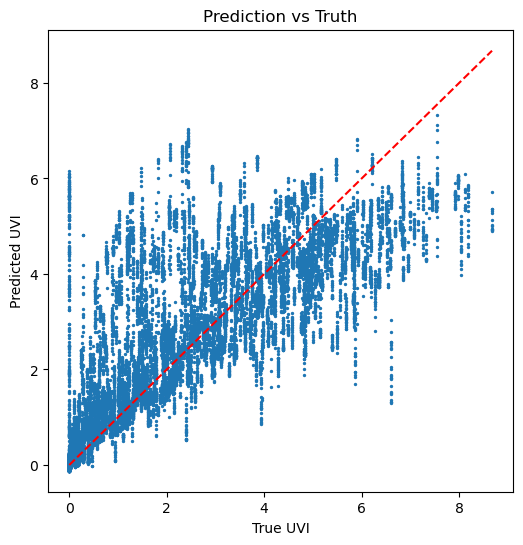

In [37]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_true_real.flatten(),
    y_pred_real.flatten(),
    s=2
)

m = max(
    y_true_real.max(),
    y_pred_real.max()
)

plt.plot([0,m],[0,m],'r--')

plt.xlabel("True UVI")
plt.ylabel("Predicted UVI")
plt.title("Prediction vs Truth")

plt.show()

In [41]:
import numpy as np
import pandas as pd
import torch

trained_model.eval()

pred_list = []
true_list = []

with torch.no_grad():

    for (
        x_enc,
        x_mark_enc,
        x_dec,
        x_mark_dec,
        target
    ) in test_loader:

        x_enc = x_enc.to(device)
        x_mark_enc = x_mark_enc.to(device)

        x_dec = x_dec.to(device)
        x_mark_dec = x_mark_dec.to(device)

        pred = trained_model(
            x_enc,
            x_mark_enc,
            x_dec,
            x_mark_dec
        )

        pred = pred.squeeze(-1)

        pred_list.append(
            pred.cpu().numpy()
        )

        true_list.append(
            target.numpy()
        )

pred_all = np.concatenate(pred_list, axis=0)
true_all = np.concatenate(true_list, axis=0)

print(pred_all.shape)
print(true_all.shape)

(2022, 24)
(2022, 24)


In [42]:
pred_inv = y_scaler.inverse_transform(
    pred_all.reshape(-1,1)
).reshape(pred_all.shape)

true_inv = y_scaler.inverse_transform(
    true_all.reshape(-1,1)
).reshape(true_all.shape)

print(pred_inv.shape)
print(true_inv.shape)

(2022, 24)
(2022, 24)


In [43]:
df_pred = pd.DataFrame(
    pred_inv,
    columns=[f"t+{i+1}" for i in range(24)]
)

df_true = pd.DataFrame(
    true_inv,
    columns=[f"t+{i+1}" for i in range(24)]
)

df_pred.to_csv(
    "Autoformer_Test_Predictions.csv",
    index=False
)

df_true.to_csv(
    "Autoformer_Test_Truth.csv",
    index=False
)

print("保存完成")

保存完成


In [44]:
pred_inv.shape
true_inv.shape

(2022, 24)

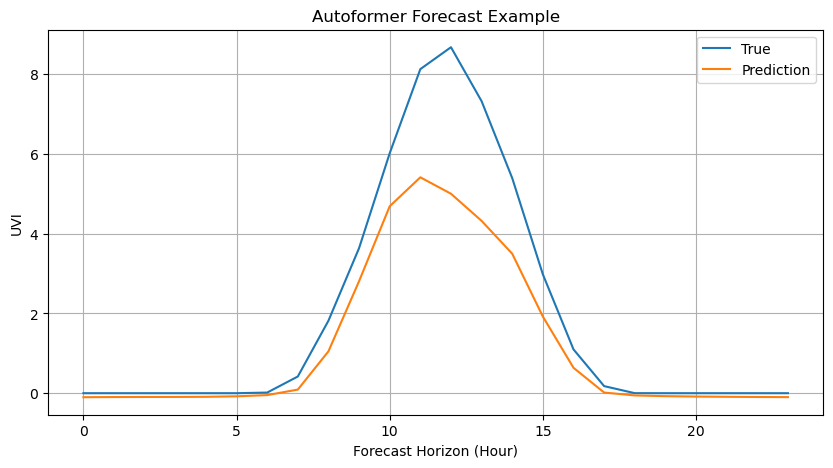

In [45]:
import matplotlib.pyplot as plt

sample = 0

plt.figure(figsize=(10,5))

plt.plot(
    true_inv[sample],
    label="True"
)

plt.plot(
    pred_inv[sample],
    label="Prediction"
)

plt.xlabel("Forecast Horizon (Hour)")
plt.ylabel("UVI")
plt.title("Autoformer Forecast Example")
plt.legend()
plt.grid(True)

plt.show()

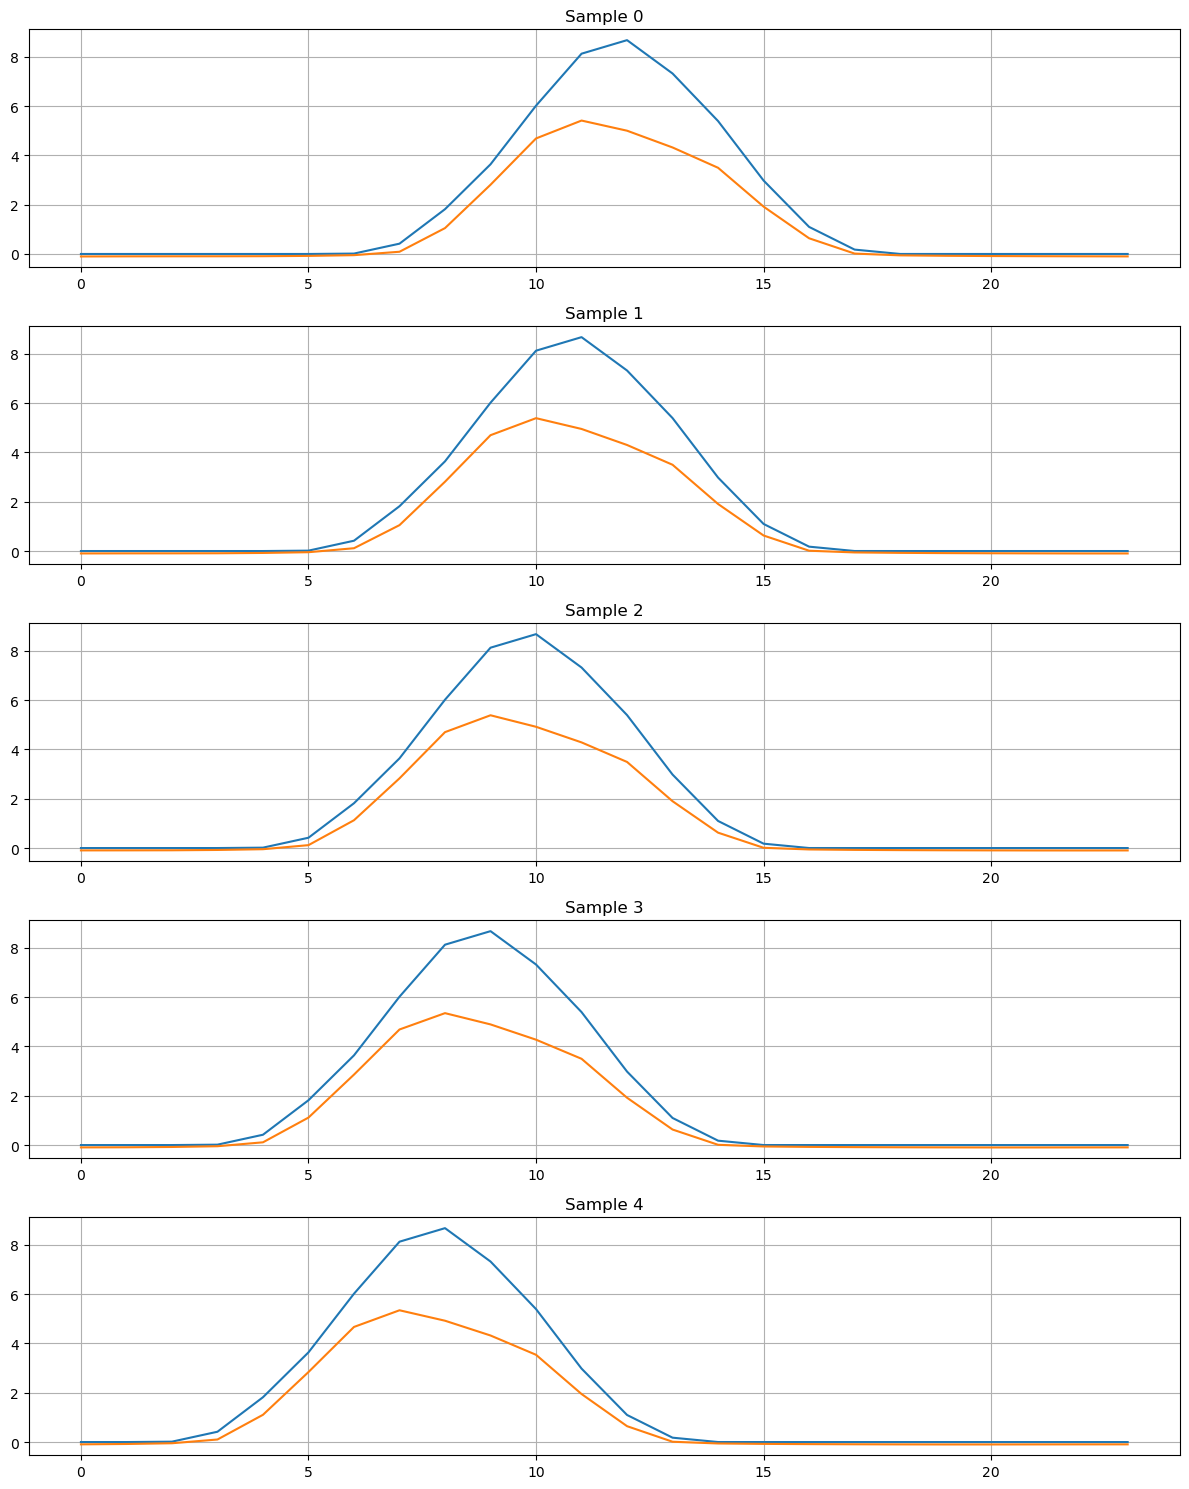

In [46]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(12,15)
)

for i in range(5):

    axes[i].plot(
        true_inv[i],
        label="True"
    )

    axes[i].plot(
        pred_inv[i],
        label="Pred"
    )

    axes[i].set_title(
        f"Sample {i}"
    )

    axes[i].grid(True)

plt.tight_layout()
plt.show()

Max Error : 6.1595726
Mean Error: 0.41335323


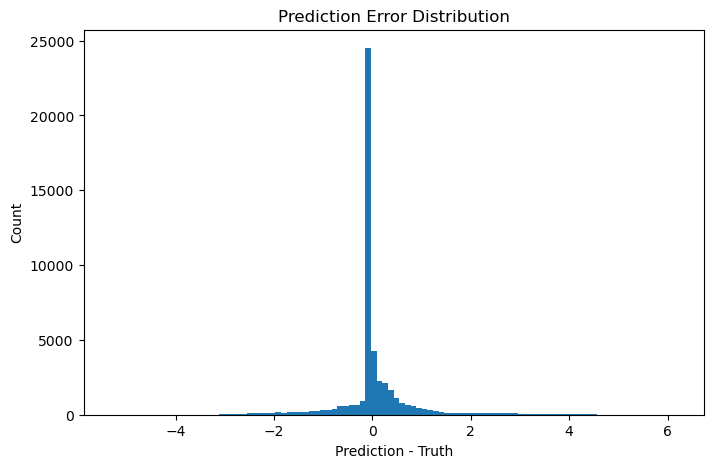

In [47]:
errors = pred_inv - true_inv

print("Max Error :", abs(errors).max())
print("Mean Error:", abs(errors).mean())

plt.figure(figsize=(8,5))

plt.hist(
    errors.flatten(),
    bins=100
)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction - Truth")
plt.ylabel("Count")

plt.show()

In [48]:
import numpy as np
import pandas as pd

errors = pred_inv - true_inv

flat_err = np.abs(errors).flatten()

idx = np.argmax(flat_err)

sample_idx = idx // 24
horizon_idx = idx % 24

print("最大误差位置:")
print("sample =", sample_idx)
print("forecast hour =", horizon_idx + 1)

print()
print("真实值 =", true_inv[sample_idx, horizon_idx])
print("预测值 =", pred_inv[sample_idx, horizon_idx])
print("误差 =", errors[sample_idx, horizon_idx])

最大误差位置:
sample = 66
forecast hour = 19

真实值 = 3.5782072e-08
预测值 = 6.1595726
误差 = 6.1595726


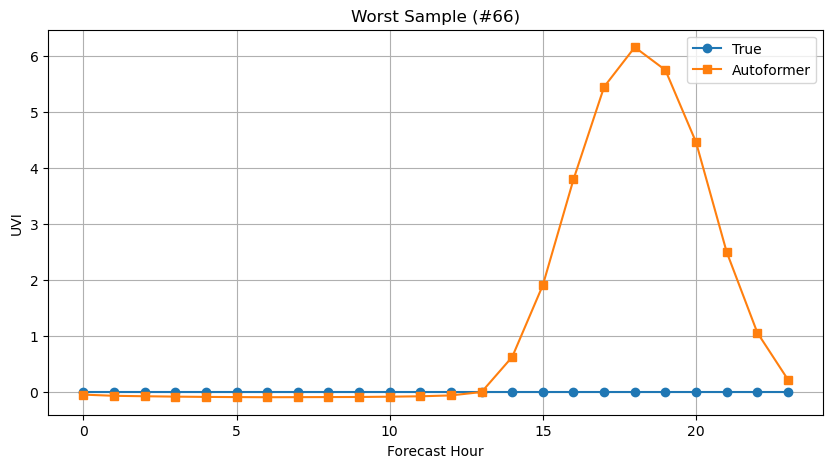

In [49]:
import matplotlib.pyplot as plt

s = sample_idx

plt.figure(figsize=(10,5))

plt.plot(
    true_inv[s],
    marker='o',
    label='True'
)

plt.plot(
    pred_inv[s],
    marker='s',
    label='Autoformer'
)

plt.title(
    f"Worst Sample (#{s})"
)

plt.xlabel("Forecast Hour")
plt.ylabel("UVI")

plt.legend()
plt.grid(True)

plt.show()

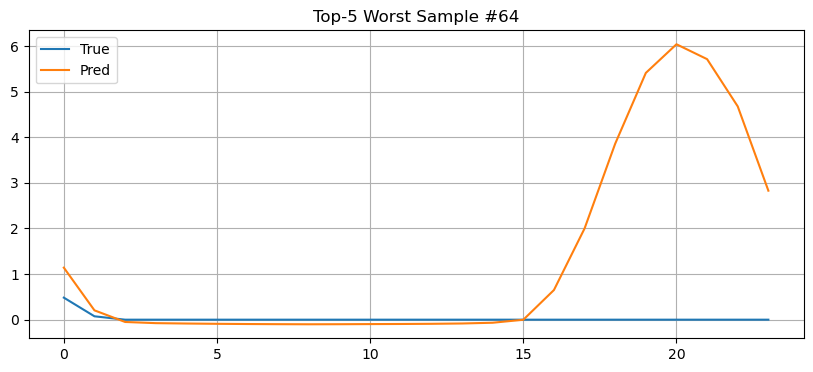

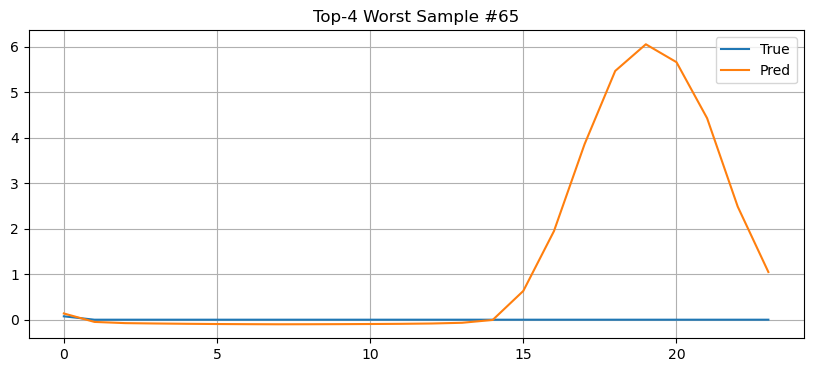

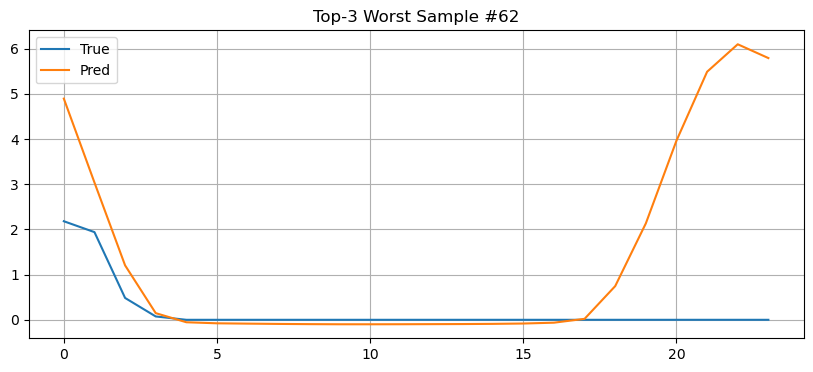

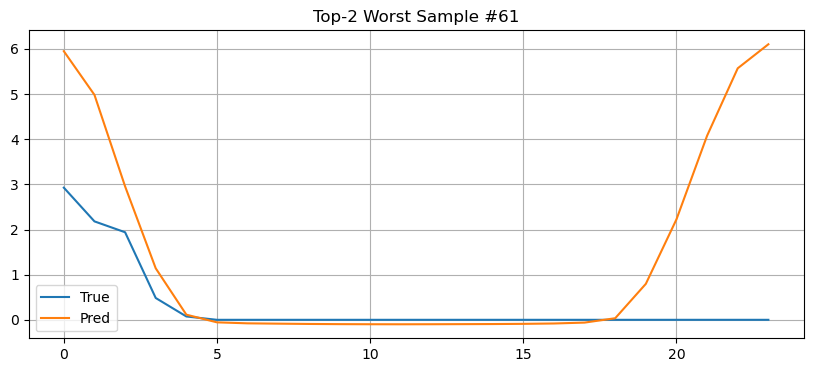

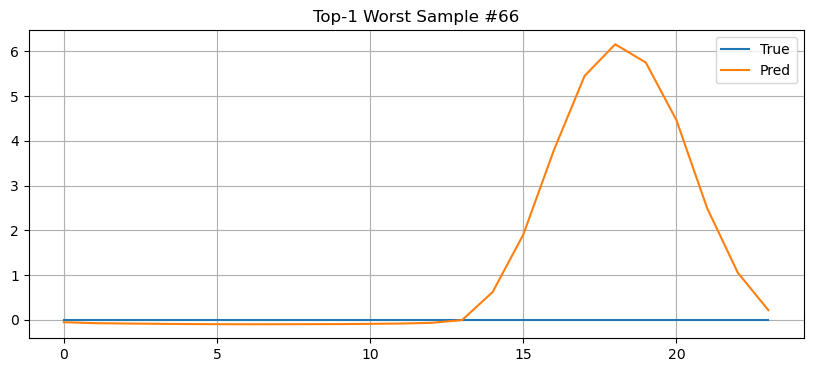

In [50]:
flat_err = np.abs(errors).flatten()

top_idx = np.argsort(flat_err)[-5:]

for k, idx in enumerate(top_idx):

    sample = idx // 24

    plt.figure(figsize=(10,4))

    plt.plot(
        true_inv[sample],
        label='True'
    )

    plt.plot(
        pred_inv[sample],
        label='Pred'
    )

    plt.title(
        f"Top-{5-k} Worst Sample #{sample}"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

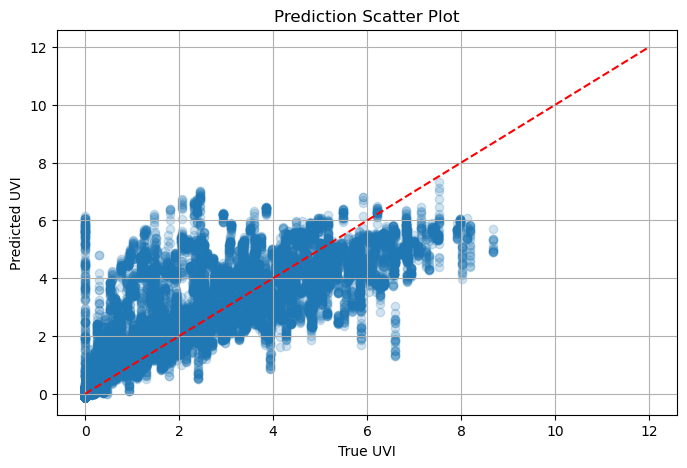

In [51]:
plt.figure(figsize=(8,5))

plt.scatter(
    true_inv.flatten(),
    pred_inv.flatten(),
    alpha=0.2
)

plt.plot(
    [0,12],
    [0,12],
    'r--'
)

plt.xlabel("True UVI")
plt.ylabel("Predicted UVI")

plt.title("Prediction Scatter Plot")

plt.grid(True)

plt.show()

In [52]:
print(feature_cols)

['temp', 'rainfall', 'windspd', 'windspd_max', 'wind_d', 'GHI', 'DNI', 'DHI', 'UVA', 'ClearSkyGHI', 'CSI', 'hour_sin', 'hour_cos', 'day_year_sin', 'day_year_cos']


In [53]:
sample = 66

print(true_inv[sample])
print()
print(pred_inv[sample])

[3.5782072e-08 3.5782072e-08 3.5782072e-08 3.5782072e-08 3.5782072e-08
 3.5782072e-08 3.5782072e-08 3.5782072e-08 3.5782072e-08 3.5782072e-08
 3.5782072e-08 3.5782072e-08 3.5782072e-08 3.5782072e-08 3.5782072e-08
 3.5782072e-08 3.5782072e-08 3.5782072e-08 3.5782072e-08 3.5782072e-08
 3.5782072e-08 3.5782072e-08 3.5782072e-08 3.5782072e-08]

[-0.05403718 -0.07530483 -0.08316609 -0.08995172 -0.09502073 -0.09826108
 -0.10059711 -0.09942683 -0.09784039 -0.09610935 -0.09105393 -0.08405229
 -0.06825503 -0.00756809  0.62084347  1.9048549   3.7950795   5.451464
  6.1595726   5.750605    4.4614115   2.497511    1.0555156   0.21478346]


In [54]:
import numpy as np

abs_err = np.abs(pred_inv - true_inv)

print("95%误差:", np.percentile(abs_err,95))
print("99%误差:", np.percentile(abs_err,99))
print("99.9%误差:", np.percentile(abs_err,99.9))
print("最大误差:", np.max(abs_err))

95%误差: 2.016942143440247
99%误差: 3.4847529220581066
99.9%误差: 5.460662761688337
最大误差: 6.1595726


In [55]:
print(test_df.index[:5])
print(test_df.index[-5:])

DatetimeIndex(['2021-10-01 00:00:00', '2021-10-01 01:00:00',
               '2021-10-01 02:00:00', '2021-10-01 03:00:00',
               '2021-10-01 04:00:00'],
              dtype='datetime64[ns]', name='time', freq=None)
DatetimeIndex(['2021-12-29 00:00:00', '2021-12-29 01:00:00',
               '2021-12-29 02:00:00', '2021-12-29 03:00:00',
               '2021-12-29 04:00:00'],
              dtype='datetime64[ns]', name='time', freq=None)


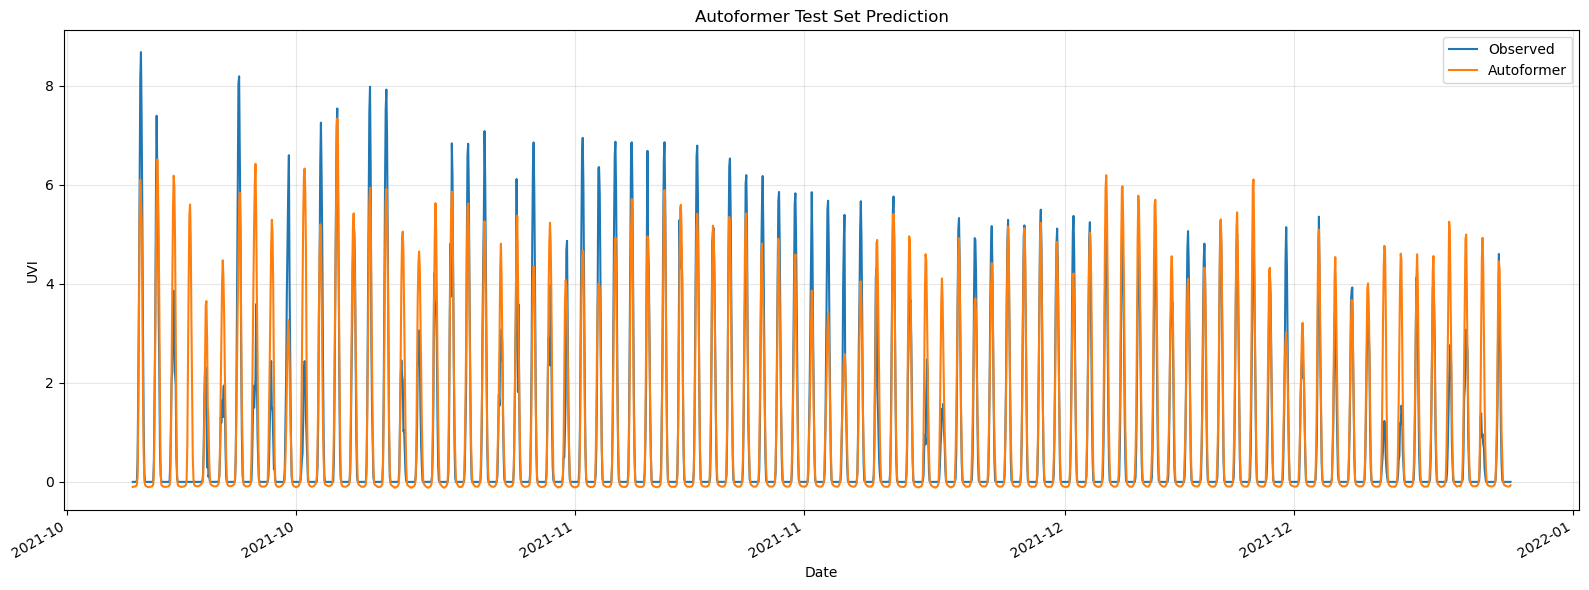

In [56]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

true_series = true_inv[:,0]
pred_series = pred_inv[:,0]

time_index = test_df.index[
    96 : 96 + len(pred_series)
]

plt.figure(figsize=(16,6))

plt.plot(
    time_index,
    true_series,
    label="Observed",
    linewidth=1.5
)

plt.plot(
    time_index,
    pred_series,
    label="Autoformer",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("UVI")

plt.title("Autoformer Test Set Prediction")

plt.legend()
plt.grid(alpha=0.3)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

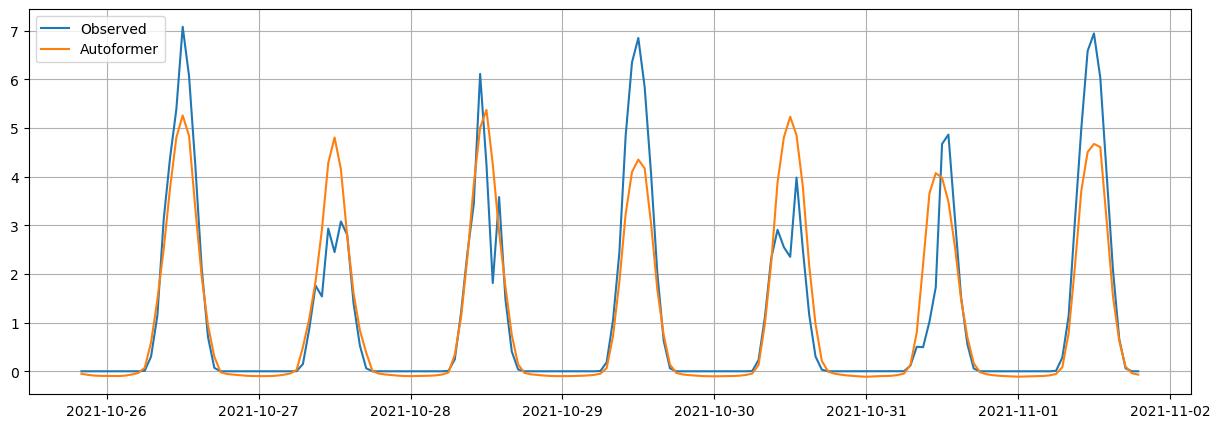

In [57]:
start = 500
days = 7

hours = days * 24

plt.figure(figsize=(15,5))

plt.plot(
    time_index[start:start+hours],
    true_series[start:start+hours],
    label="Observed"
)

plt.plot(
    time_index[start:start+hours],
    pred_series[start:start+hours],
    label="Autoformer"
)

plt.legend()
plt.grid()
plt.show()